# 09a — Introduzione alla libreria client OpenAI

**Corso**: Programmazione di Applicazioni Intelligenti  
**Lezione 09** — Dal Client OpenAI al Function Calling e MCP  
**Blocco 1** — Teoria (30 min)

In questo notebook esploreremo la libreria Python `openai` come interfaccia universale per interagire con i Large Language Model. Vedremo come:

- Configurare il client per diversi provider (Groq, OpenAI, Ollama)
- Effettuare una chat completion e comprendere la struttura della risposta
- Generare risposte multiple con il parametro `n`
- Usare lo streaming per una UX reattiva
- Comprendere la differenza tra reasoning token e completion token
- Gestire conversazioni multi-turno simulando la memoria
- Ottenere output strutturato con Pydantic e constrained decoding


---
## 1.1 — Il client OpenAI come standard de facto

La libreria Python `openai` è diventata lo **standard de facto** per interagire con i LLM via API. Il suo punto di forza? **Stesso codice, provider diversi**. Basta cambiare il `base_url` per passare da OpenAI a Groq, Ollama, vLLM, o qualsiasi altro provider compatibile.

Questo è possibile perché quasi tutti i provider hanno adottato il formato delle API OpenAI (la cosiddetta "OpenAI-compatible API"). In pratica, impari un'unica interfaccia e puoi usare decine di modelli diversi.

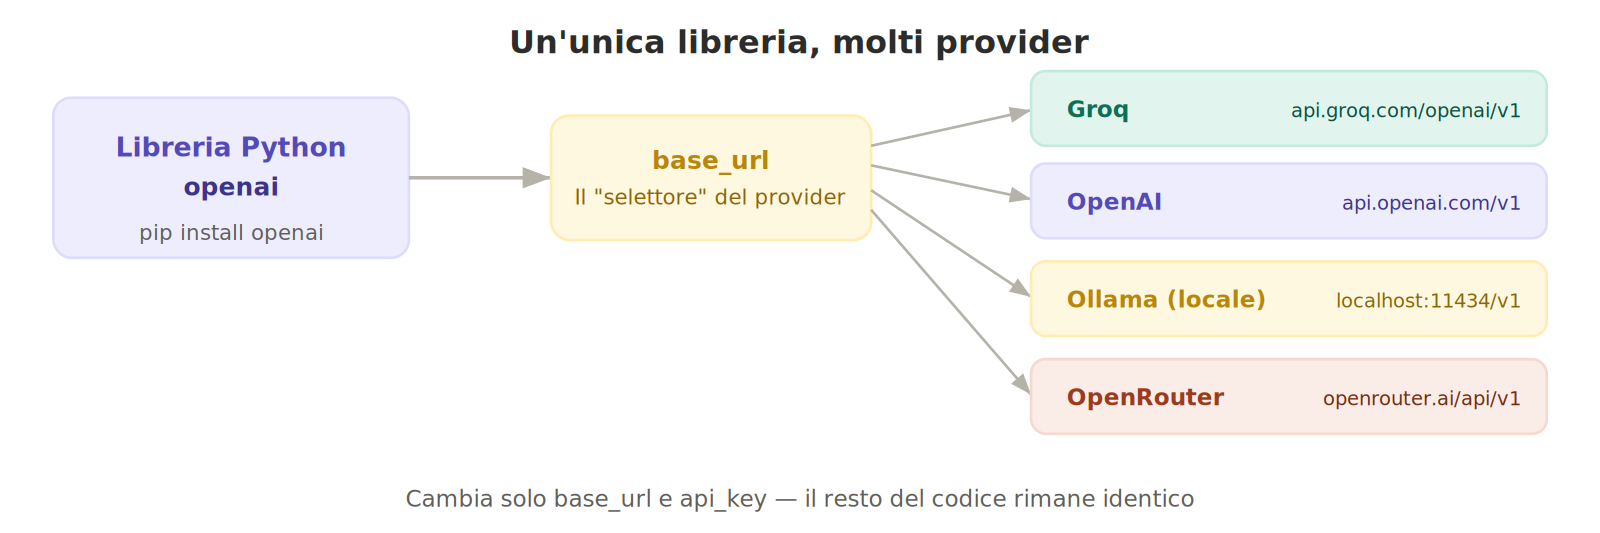

### Setup: 3 righe per iniziare

Il setup minimale richiede solo di installare la libreria, importarla, e creare un client con il `base_url` del provider scelto. Oggi useremo **Groq** con il modello **gpt-oss-120b**.

**Perché Groq?** Groq produce chip specializzati per l'inferenza LLM (le LPU — Language Processing Unit), offrendo velocità eccezionali. Il free tier permette 30 richieste al minuto e 1.000 al giorno per account — più che sufficiente per le nostre esercitazioni.

**Perché gpt-oss-120b?** È il modello open-weight di punta di OpenAI: architettura MoE da 117B parametri totali (5.1B attivi per token), licenza Apache 2.0, supporta reasoning configurabile, tool calling nativo e structured output. Context window: 131K token.


In [2]:
# Setup: installazione e configurazione del client
!pip install -q openai

from openai import OpenAI
from google.colab import userdata

# Configurazione del client per Groq
client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=userdata.get("GROQ_API_KEY"),  # Chiave salvata nei Secrets di Colab
)

# Modello che useremo per tutta la lezione
MODEL = "openai/gpt-oss-120b"

print("Client configurato!")
print(f"Provider: Groq (api.groq.com)")
print(f"Modello:  {MODEL}")


Client configurato!
Provider: Groq (api.groq.com)
Modello:  openai/gpt-oss-120b


> **Nota per il docente**: prima di eseguire questa cella, gli studenti devono:
> 1. Creare un account gratuito su [console.groq.com](https://console.groq.com)
> 2. Generare una API key nella sezione API Keys
> 3. In Colab: menu laterale → icona chiave (Secrets) → aggiungere il secret `GROQ_API_KEY`
>
> **Rate limit free tier Groq** (per account): 30 RPM, 1.000 RPD, 8.000 TPM, 200.000 TPD. Ogni studente ha il proprio account con i propri limiti.
>
> **Portabilità**: siccome usiamo la libreria `openai` standard, per passare a un altro provider basta cambiare `base_url` e `api_key`. Lo stesso codice funziona con OpenAI diretto, OpenRouter, Ollama locale, ecc.


---
## 1.2 — La prima chiamata: chat completion

L'endpoint principale della libreria è `chat.completions.create()`. Il suo input è una lista di **messaggi**, ciascuno con un **ruolo** e un **contenuto**. La risposta contiene una lista `choices` — vediamo perché.

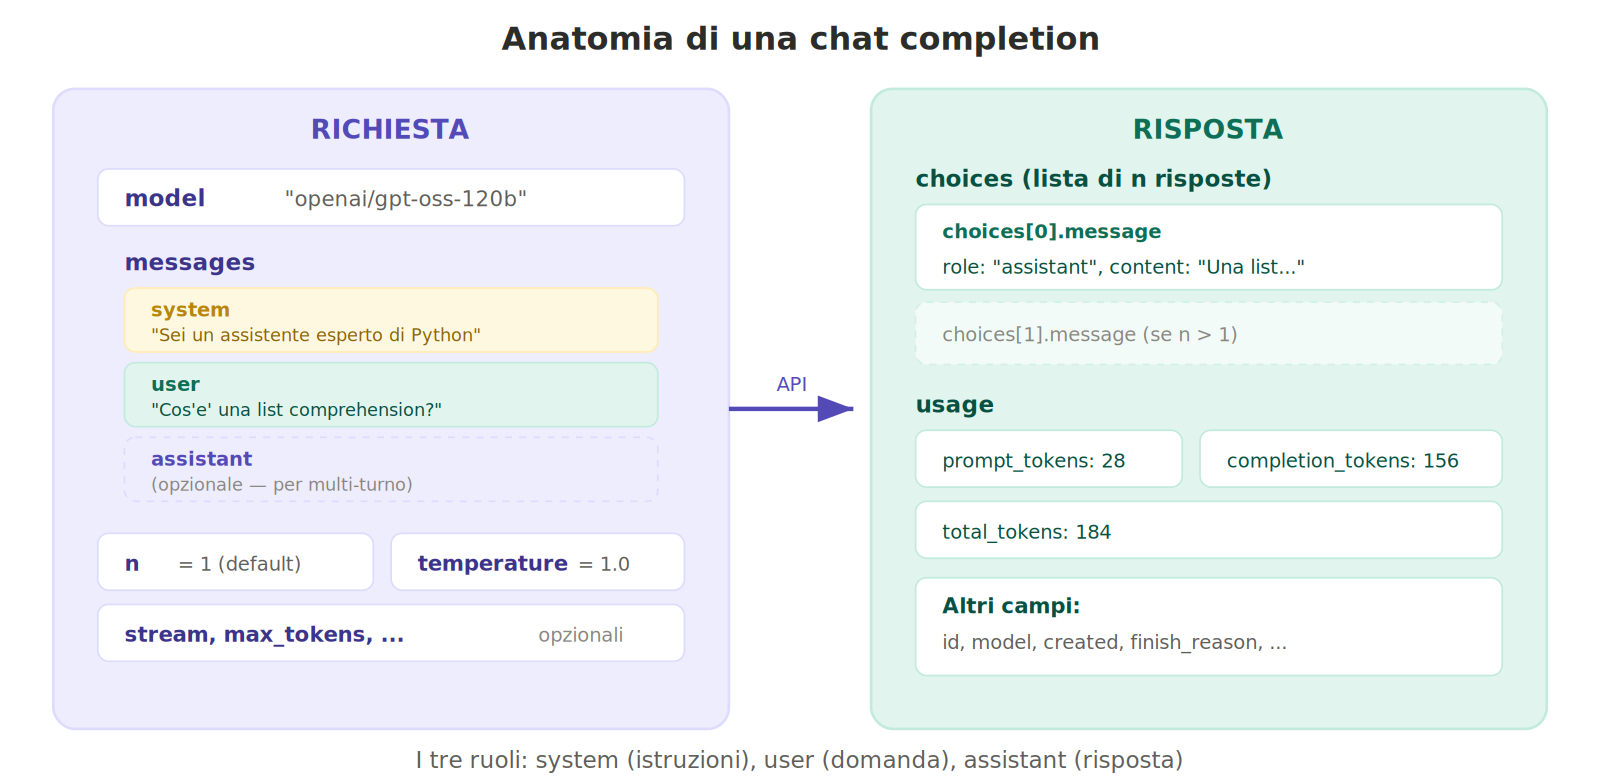

### I tre ruoli

- **`system`** — Istruzioni per il modello: definisce il comportamento, il tono, i vincoli. È il "brief" che dai all'assistente prima che inizi a lavorare.
- **`user`** — Il messaggio dell'utente: la domanda, la richiesta, l'input.
- **`assistant`** — La risposta del modello. Nelle conversazioni multi-turno, si include anche questo ruolo per dare al modello la "memoria" delle risposte precedenti.


In [3]:
# La prima chiamata: una domanda semplice
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "Sei un assistente esperto di programmazione Python. Rispondi in italiano, in modo conciso."},
        {"role": "user", "content": "Cos'è una list comprehension in Python? Fai un esempio."}
    ]
)

# Estrarre la risposta
risposta = response.choices[0].message.content
print(risposta)


Una **list comprehension** è un modo compatto e leggibile per creare una lista a partire da un iterabile, applicando un’espressione a ciascun elemento e, opzionalmente, filtrando con una condizione.

**Sintassi generale**

```python
nuova_lista = [espressione(elemento) for elemento in iterable if condizione]
```

- `espressione(elemento)`: ciò che verrà inserito nella nuova lista (può essere l’elemento stesso o una trasformazione).
- `for elemento in iterable`: ciclo sull’iterabile di partenza.
- `if condizione` (opzionale): filtro che include solo gli elementi che soddisfano la condizione.

**Esempio pratico**

Supponiamo di voler ottenere i quadrati dei numeri pari da 0 a 9:

```python
quadrati_pari = [x**2 for x in range(10) if x % 2 == 0]
print(quadrati_pari)   # Output: [0, 4, 16, 36, 64]
```

Qui:
- `range(10)` genera i numeri 0‑9.
- `if x % 2 == 0` filtra solo i numeri pari.
- `x**2` è l’espressione che calcola il quadrato di ciascun numero selezionato.


In [4]:
# Esplorazione dell'oggetto response
print(f"Modello usato: {response.model}")
print(f"Token di input (prompt):      {response.usage.prompt_tokens}")
print(f"Token di output (completion): {response.usage.completion_tokens}")
print(f"Token totali:                 {response.usage.total_tokens}")
print(f"Motivo di fine generazione:   {response.choices[0].finish_reason}")
print(f"Numero di choices:            {len(response.choices)}")


Modello usato: openai/gpt-oss-120b
Token di input (prompt):      110
Token di output (completion): 343
Token totali:                 453
Motivo di fine generazione:   stop
Numero di choices:            1


> **Nota per il docente**: far notare che `finish_reason` può essere:
> - `"stop"` — il modello ha terminato naturalmente
> - `"length"` — ha raggiunto il limite di `max_tokens`
> - `"tool_calls"` — il modello vuole invocare un tool (lo vedremo nel Blocco 3)
>
> Il conteggio dei token è fondamentale per i costi. Nel free tier non paghiamo, ma in produzione ogni token ha un prezzo. Formula: costo = (prompt_tokens × prezzo_input + completion_tokens × prezzo_output) / 1.000.000.


### Perché `choices` è una lista? Il parametro `n`

Avrete notato che accediamo alla risposta con `choices[0]` — perché `[0]` e non direttamente `.message`? Perché l'API permette di richiedere **più risposte indipendenti** con il parametro `n`. Ogni risposta viene generata con un sampling diverso, quindi possono essere diverse tra loro.

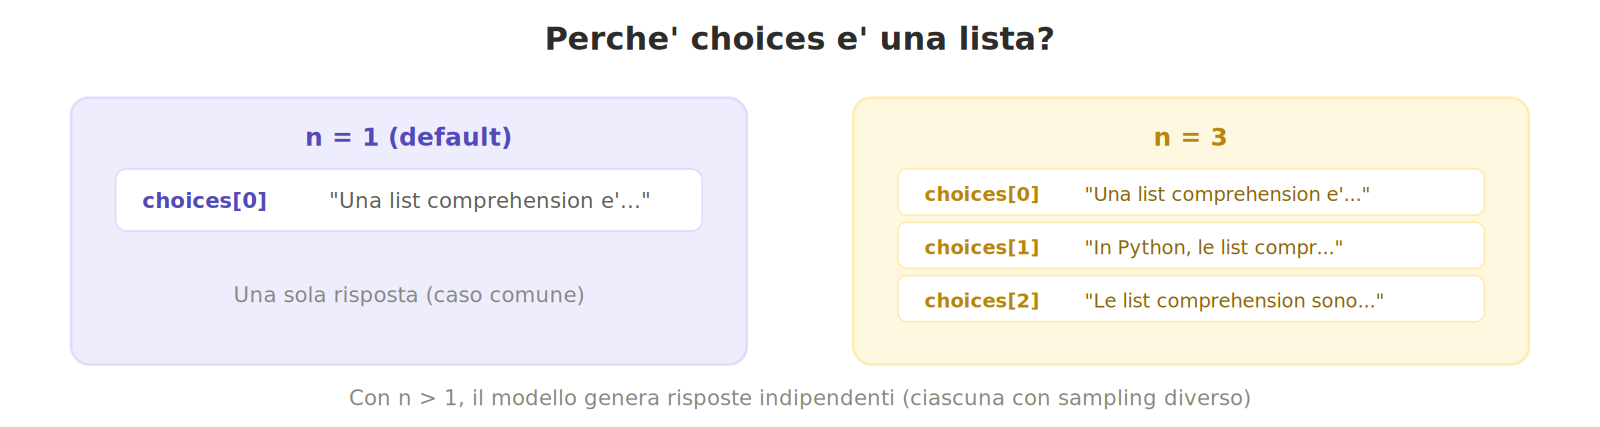

In [5]:
# Demo: generare 3 risposte diverse con n=3
# Non funziona con Groq!
response_multi = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Suggeriscimi un nome creativo per un gatto arancione. Rispondi con un solo nome."}
    ],
    n=3,
    temperature=1.0,  # più alta = più varietà tra le risposte
)

for i, choice in enumerate(response_multi.choices):
    print(f"Risposta {i}: {choice.message.content.strip()}")

print(f"\nToken totali: {response_multi.usage.total_tokens} (il costo scala con n!)")


BadRequestError: Error code: 400 - {'error': {'message': "'n' : number must be at most 1", 'type': 'invalid_request_error'}}

> **Nota per il docente**: nella pratica `n=1` è il caso comune. Il parametro `n > 1` è utile in scenari specifici: generare candidati per poi scegliere il migliore (best-of-n), esplorare la varietà delle risposte, o testing. Attenzione: il costo dei completion token scala linearmente con `n`. Non tutti i provider supportano `n > 1` sul free tier — se Groq restituisce un errore, è normale: mostrare il concetto è sufficiente.


---
## 1.3 — Streaming: risposta token per token

Quando il modello genera una risposta lunga, con la chiamata standard l'utente deve **aspettare in silenzio** finché l'intera risposta è pronta. Con lo **streaming**, invece, i token arrivano uno alla volta — esattamente come quando ChatGPT "scrive" la risposta in tempo reale.

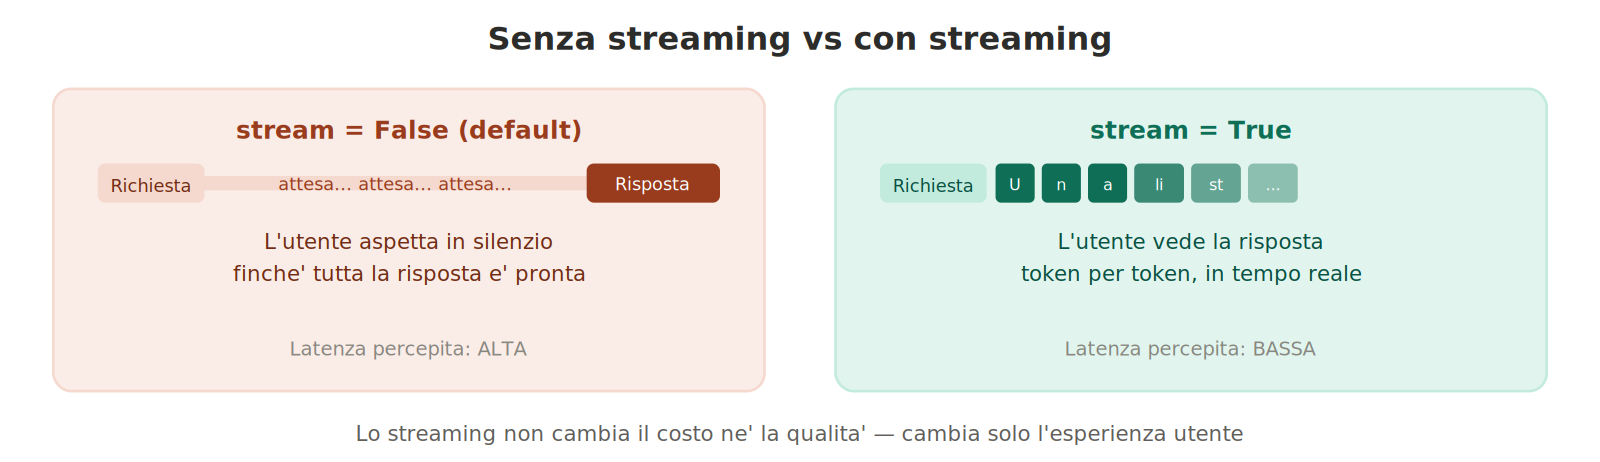

In [7]:
# Demo: streaming — la risposta arriva token per token
import time

stream = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Spiega in 3 frasi cos'è il machine learning."}
    ],
    stream=True,  # <-- l'unica differenza!
)

# Iteriamo sui chunk man mano che arrivano
print("Risposta in streaming:")
for chunk in stream:
    # Ogni chunk contiene un frammento (delta) della risposta
    delta = chunk.choices[0].delta
    if delta.content:
        print(delta.content, end="", flush=True)

print()  # newline finale


Risposta in streaming:
Il machine learning è una branca dell'intelligenza artificiale che permette ai computer di apprendere automaticamente da dati, senza essere esplicitamente programmati per ogni compito. Utilizza algoritmi statistici per identificare pattern, fare previsioni o prendere decisioni basate su esempi precedenti. Man mano che vengono forniti nuovi dati, il modello si aggiorna e migliora le proprie prestazioni.


In [ ]:
# Confronto: stessa domanda SENZA streaming
start = time.time()
response_no_stream = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Spiega in 3 frasi cos'è il machine learning."}
    ],
    stream=False,
)
elapsed = time.time() - start

print(f"Risposta completa (attesa {elapsed:.1f}s):")
print(response_no_stream.choices[0].message.content)


Risposta completa (attesa 0.5s):
Il machine learning è un ramo dell'intelligenza artificiale che permette ai computer di apprendere autonomamente da dati ed esperienze, senza essere programmati esplicitamente per ogni compito. Utilizza algoritmi statistici che identificano pattern, fanno previsioni o prendono decisioni basate su esempi precedenti. In pratica, più dati vengono forniti al modello, più migliora la sua capacità di generalizzare e di risolvere problemi complessi.


### Cosa cambia con lo streaming?

| | **Senza streaming** | **Con streaming** |
|---|---|---|
| **Come arriva la risposta** | Tutta insieme, alla fine | Token per token, in tempo reale |
| **Latenza percepita** | Alta (silenzio → risposta) | Bassa (primo token quasi subito) |
| **Costo** | Identico | Identico |
| **Qualità della risposta** | Identica | Identica |
| **Oggetto restituito** | `ChatCompletion` | Iteratore di `ChatCompletionChunk` |
| **Accesso a `usage`** | Sì, nell'oggetto response | Dipende dal provider (spesso nell'ultimo chunk) |

Lo streaming è la norma nelle applicazioni reali (ChatGPT, Claude, Copilot lo usano tutti).

> **Nota per il docente**: lo streaming è fondamentale per la UX ma non cambia nulla sul piano del modello: la generazione avviene comunque token per token internamente. Lo streaming semplicemente espone questo processo all'utente. Groq, grazie alle LPU, è particolarmente veloce in streaming — gli studenti dovrebbero notare che i token arrivano molto rapidamente.


---
## 1.4 — Reasoning token vs completion token

Alcuni modelli recenti (o1, o3, gpt-oss-120b, DeepSeek-R1) sono detti **modelli "thinking"**: prima di rispondere, generano una catena di ragionamento interna. Questi token si chiamano **reasoning token** e di solito non sono visibili nella risposta finale.

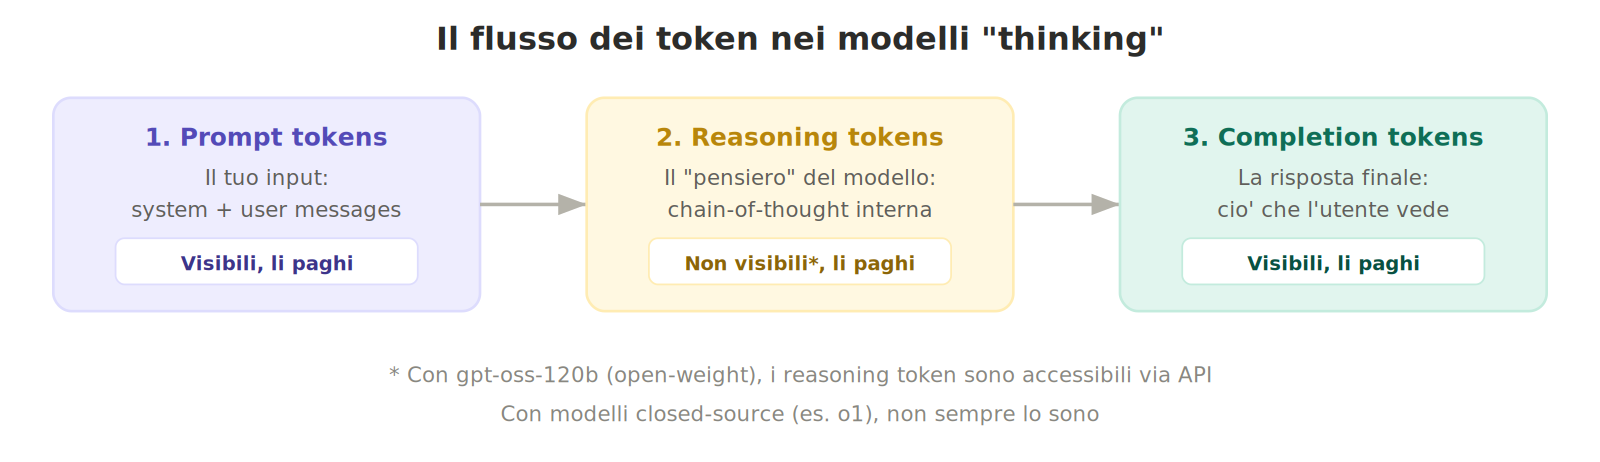

### Confronto reasoning token vs completion token

|  | **Reasoning token** | **Completion token** |
|---|---|---|
| **Cosa sono** | Il ragionamento interno del modello (chain-of-thought) | La risposta finale visibile all'utente |
| **Visibilità** | Dipende dal modello e provider — con gpt-oss-120b sono accessibili | Sempre visibili |
| **Costo** | Conteggiati come output token (stesso prezzo) | Conteggiati come output token |
| **Latenza** | Aumentano il tempo di risposta (il modello "pensa" di più) | Tempo proporzionale alla lunghezza |
| **Modelli** | o1, o3, gpt-oss-120b, DeepSeek-R1 | Tutti i modelli |
| **Configurabile?** | Sì, con il parametro `reasoning_effort` | Sì, con `max_tokens` |


In [11]:
# Demo: abilitare il reasoning con gpt-oss-120b su Groq
response_thinking = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Quanti numeri primi ci sono tra 1 e 50?"}
    ],
    reasoning_effort="medium",  # "low", "medium", "high"
)

msg = response_thinking.choices[0].message

# Reasoning (la chain-of-thought del modello)
if hasattr(msg, 'reasoning') and msg.reasoning:
    print("=== REASONING (primi 800 caratteri) ===")
    print(msg.reasoning)
    if len(msg.reasoning) > 800:
        print("...")
    print()

# La risposta finale
print("=== RISPOSTA ===")
print(msg.content)
print()

# Token consumati
usage = response_thinking.usage
print(f"Prompt tokens:     {usage.prompt_tokens}")
print(f"Completion tokens: {usage.completion_tokens}")
print(f"Total tokens:      {usage.total_tokens}")

if hasattr(usage, 'completion_tokens_details') and usage.completion_tokens_details:
    details = usage.completion_tokens_details
    if hasattr(details, 'reasoning_tokens') and details.reasoning_tokens:
        print(f"  di cui reasoning: {details.reasoning_tokens}")

=== REASONING (primi 800 caratteri) ===
We need to answer in Italian. The user asks: "Quanti numeri primi ci sono tra 1 e 50?" So we list primes between 1 and 50 inclusive and count them.

Prime numbers from 2 to 47: 2,3,5,7,11,13,17,19,23,29,31,37,41,43,47. Also prime 53 > 50, not included. Also 2,3,5,7,11,13,17,19,23,29,31,37,41,43,47. That's 15 primes.

Check if 1 is considered prime? No, 1 is not prime. So answer: 15. Provide list.

=== RISPOSTA ===
Tra 1 e 50 ci sono **15 numeri primi**.  

Eccoli elencati:

2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47.

Prompt tokens:     85
Completion tokens: 230
Total tokens:      315
  di cui reasoning: 155


> **Nota per il docente**: il parametro `reasoning_effort` controlla quanta "riflessione" il modello dedica:
> - `"low"` — risposta veloce, poco ragionamento
> - `"medium"` — bilanciato
> - `"high"` — ragionamento approfondito, più lento ma più accurato
>
> Il trade-off è chiaro: più reasoning = più token = più latenza, ma potenzialmente risposte migliori per problemi complessi. Per domande semplici è uno spreco.
>
> gpt-oss-120b è open-weight (Apache 2.0), quindi il reasoning è trasparente. Con modelli proprietari come o1, i reasoning token sono nascosti ma comunque fatturati.


---
## 1.5 — Conversazioni multi-turno: simulare la memoria

Concetto fondamentale: **l'LLM è stateless**. Ogni chiamata API è un evento isolato — il modello non "ricorda" le chiamate precedenti. Se vogliamo una conversazione coerente, dobbiamo **re-iniettare tutta la cronologia** ad ogni turno.

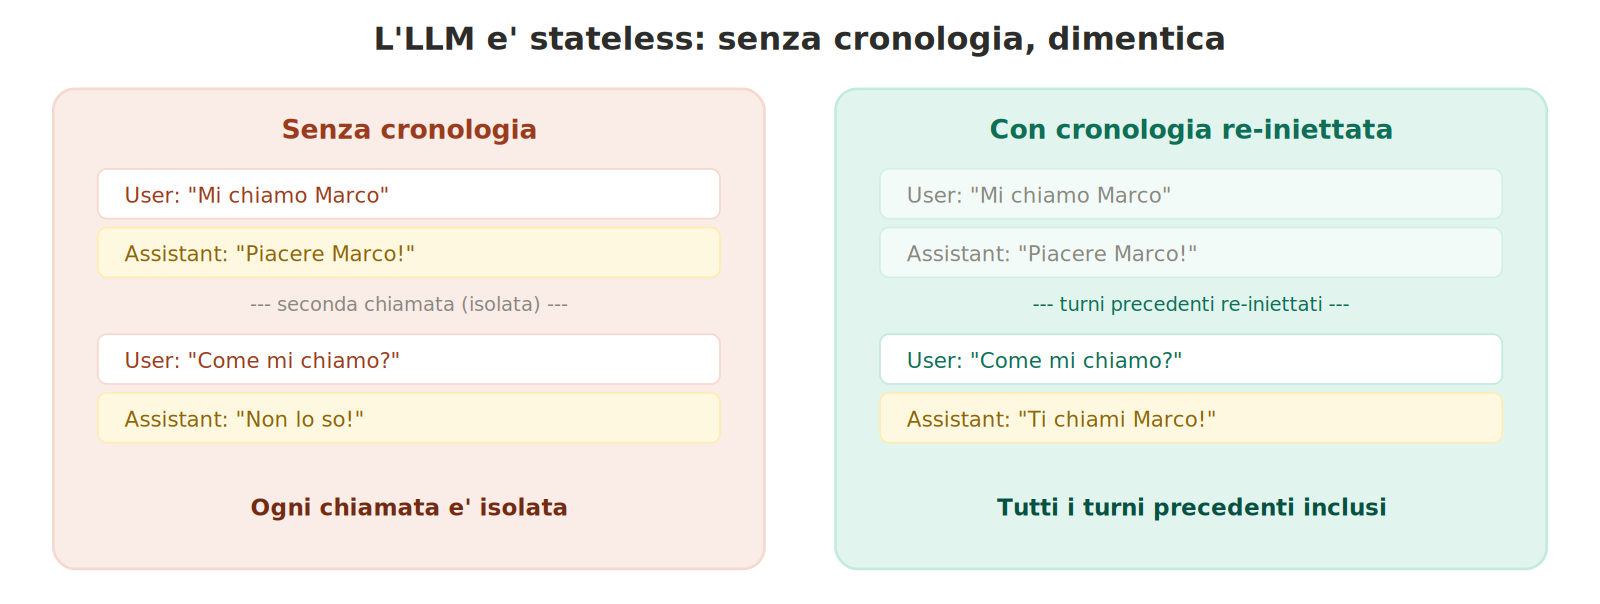

In [12]:
# Demo: senza cronologia — il modello dimentica

# Turno 1
response_1 = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Mi chiamo Marco e studio informatica a Vercelli."}
    ]
)
print("Turno 1:", response_1.choices[0].message.content)

# Turno 2 — chiamata separata, SENZA cronologia
response_2 = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Come mi chiamo e cosa studio?"}
    ]
)
print("\nTurno 2 (senza cronologia):", response_2.choices[0].message.content)


Turno 1: Ciao Marco! È un piacere conoscerti. Come trovi il corso di informatica a Vercelli? Se hai domande, curiosità o progetti su cui stai lavorando, fammi sapere: sono qui per darti una mano!

Turno 2 (senza cronologia): Non ho informazioni su di te, quindi non conosco il tuo nome né il campo di studio a cui ti dedichi. Se vuoi, puoi dirmi queste informazioni e sarò felice di aiutarti con qualsiasi domanda o dubbio tu abbia!


In [13]:
# Demo: con cronologia — il modello "ricorda"

cronologia = [
    {"role": "user", "content": "Mi chiamo Marco e studio informatica a Vercelli."},
    {"role": "assistant", "content": response_1.choices[0].message.content},
    {"role": "user", "content": "Come mi chiamo e cosa studio?"}
]

response_3 = client.chat.completions.create(
    model=MODEL,
    messages=cronologia
)
print("Turno 2 (con cronologia):", response_3.choices[0].message.content)


Turno 2 (con cronologia): Ti chiami **Marco** e studi **informatica** a Vercelli.


### Il costo della "memoria": token crescenti ad ogni turno

Ogni volta che aggiungiamo un turno, ri-inviamo **tutti i messaggi precedenti**. Il numero di prompt token cresce linearmente.

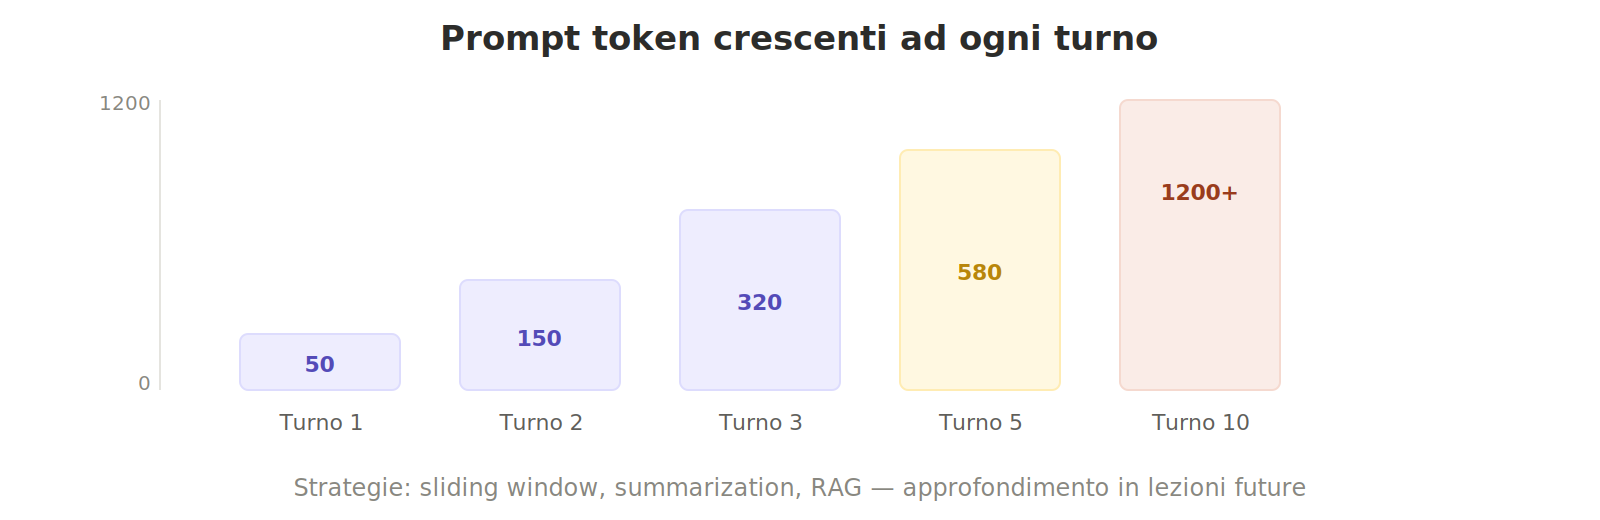

> **Nota per il docente**: anticipare il concetto di **Context Engineering** — come gestire la finestra di contesto quando le conversazioni si allungano. Strategie: sliding window (ultimi N turni), summarization (riassumere i turni vecchi), RAG (recuperare solo le info rilevanti). Saranno trattate in lezioni dedicate. Per ora basta capire **il problema** della crescita lineare.


---
## 1.6 — Output strutturato: da testo libero a dati

### Il problema

L'LLM produce **testo naturale**. Ma il nostro codice ha bisogno di **dati strutturati**: numeri, liste, dizionari. Come fare?

Due approcci:
1. **"Pregare il modello"** — chiedere nel prompt "rispondi in JSON" e sperare che lo faccia (fragile, può sbagliare)
2. **Constrained decoding** — il modello è **obbligato** a produrre output valido rispetto a uno schema (robusto, garantito)

L'API OpenAI supporta il secondo approccio con `response_format` e le classi **Pydantic**.

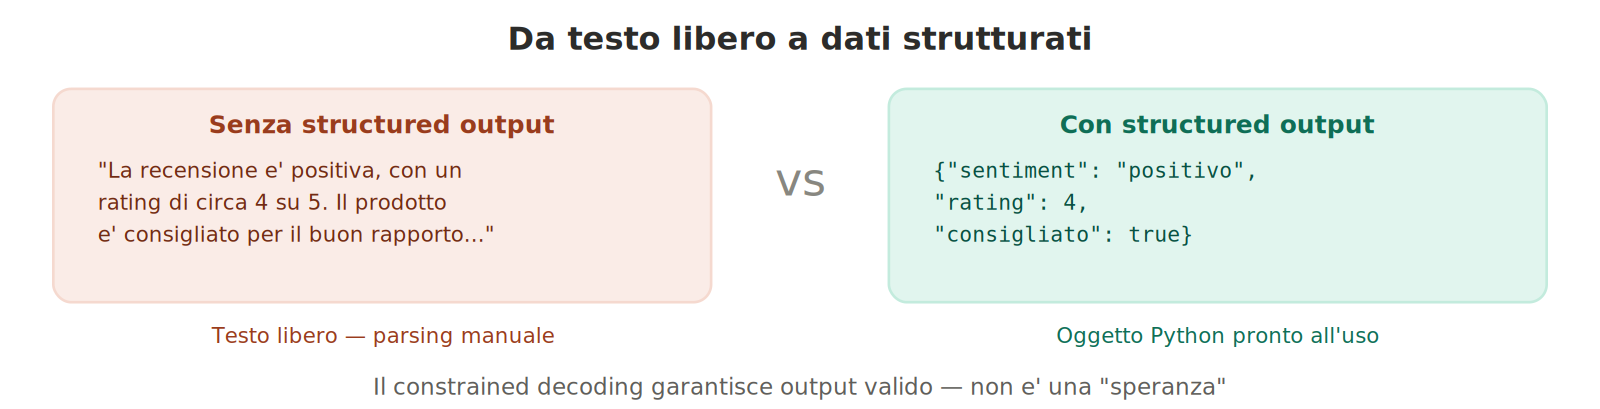

In [17]:
# Structured output con Pydantic
from pydantic import BaseModel
from typing import List

# Definiamo lo schema dell'output desiderato
class RecensioneAnalisi(BaseModel):
    titolo: str
    sentiment: str  # "positivo", "negativo", "neutro"
    rating: int     # da 1 a 5
    pro: List[str]
    contro: List[str]
    consigliato: bool

recensione = """
Ho comprato questo zaino per l'universita' e devo dire che sono molto soddisfatto.
Il tessuto e' resistente, le cerniere scorrono bene, e ci stanno comodamente
il laptop da 15 pollici e tutti i libri. L'unico difetto e' che le spalline
avrebbero potuto essere piu' imbottite per chi lo porta pieno tutto il giorno.
Ottimo rapporto qualita'-prezzo, lo consiglio!
"""

response_struct = client.beta.chat.completions.parse(
    model=MODEL,
    messages=[
        {"role": "system", "content": "Analizza la recensione e restituisci i dati strutturati richiesti."},
        {"role": "user", "content": recensione}
    ],
    response_format=RecensioneAnalisi,
)

# L'output e' un oggetto Python tipizzato, non una stringa!
analisi = response_struct.choices[0].message.parsed
print(f"Titolo:       {analisi.titolo}")
print(f"Sentiment:    {analisi.sentiment}")
print(f"Rating:       {analisi.rating}/5")
print(f"Pro:          {analisi.pro}")
print(f"Contro:       {analisi.contro}")
print(f"Consigliato:  {analisi.consigliato}")


Titolo:       Zaino per università
Sentiment:    positivo
Rating:       5/5
Pro:          ['tessuto resistente', 'cerniere scorrevoli', 'spazio per laptop da 15 pollici', 'spazio per tutti i libri', 'ottimo rapporto qualità-prezzo']
Contro:       ['spalline poco imbottite per chi lo porta pieno tutto il giorno']
Consigliato:  True


In [18]:
# L'oggetto Pydantic si converte facilmente in dizionario
import json

# Usa model_dump_json() per ottenere una stringa JSON e poi json.loads() per analizzarla.
# Oppure, se vuoi stampare direttamente, puoi usare print(analisi.model_dump_json(indent=2))
print(json.dumps(analisi.model_dump(), indent=2))

{
  "titolo": "Zaino per universit\u00e0",
  "sentiment": "positivo",
  "rating": 5,
  "pro": [
    "tessuto resistente",
    "cerniere scorrevoli",
    "spazio per laptop da 15 pollici",
    "spazio per tutti i libri",
    "ottimo rapporto qualit\u00e0-prezzo"
  ],
  "contro": [
    "spalline poco imbottite per chi lo porta pieno tutto il giorno"
  ],
  "consigliato": true
}


### Perché è importante?

Lo structured output è il fondamento del **function calling** (che vedremo nel Blocco 3):
- Il modello deve produrre un JSON con il nome della funzione e i suoi argomenti
- Se il JSON fosse malformato, il nostro codice non saprebbe cosa eseguire
- Il constrained decoding **garantisce** che l'output sia sempre valido

In altre parole: lo structured output è ciò che permette all'LLM di "parlare" con il codice in modo affidabile.


> **Nota per il docente**: sottolineare la differenza tra:
> 1. **Prompting** ("rispondi in JSON") — funziona spesso, ma il modello può sbagliare, aggiungere testo extra, produrre JSON non valido
> 2. **Constrained decoding** (`response_format`) — il modello è vincolato token per token a produrre output conforme allo schema. Non è una "richiesta" — è un vincolo hard sulla generazione
>
> Tecnicamente, il constrained decoding modifica le probabilità dei token durante la generazione: i token che violerebbero lo schema ricevono probabilità zero.
>
> `client.beta.chat.completions.parse()` è ancora in beta nella libreria `openai`, ma è stabile e ampiamente usato in produzione.


---
## Riepilogo

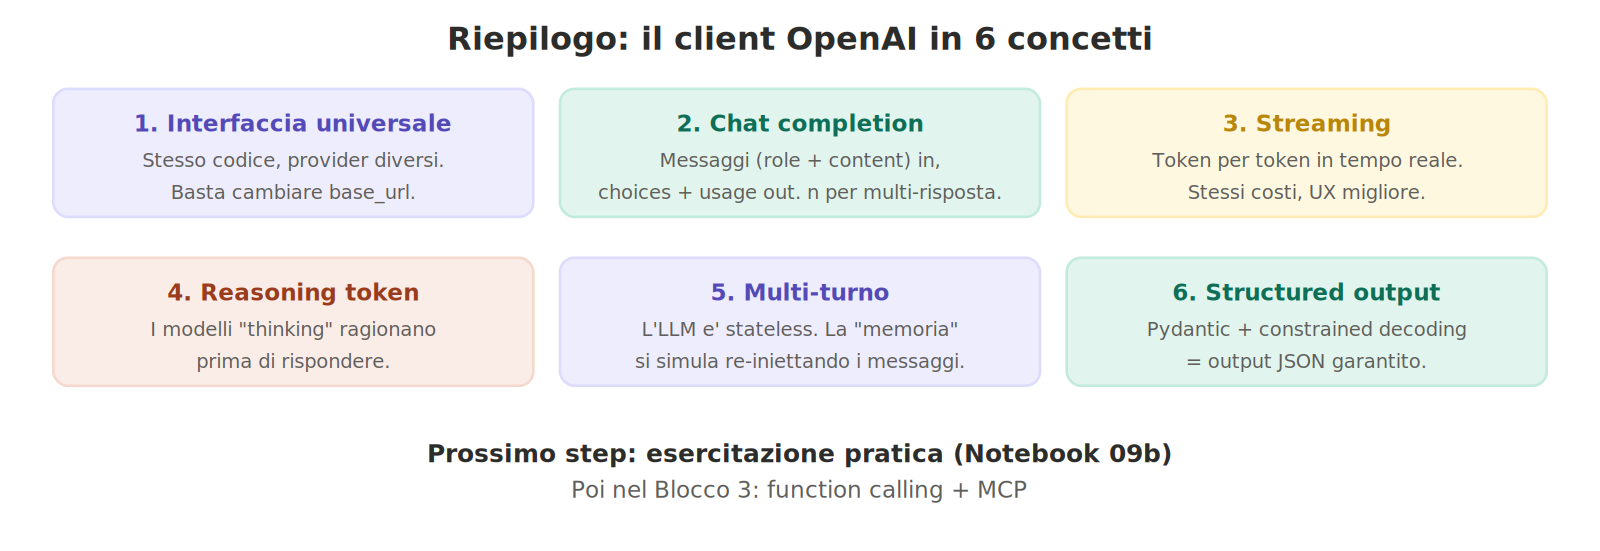